# Always run in order, with clean kernel. Some variables overwrite 

# Importa moduli di terze parti

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re

# Importa moduli toolbox


In [2]:
from toolbox.plots.Plot import create_accuracy_boxplot, create_f1score_boxplot, get_animal_data, w_compare_acc_boxplots, w_compare_f1_boxplots
from toolbox.functions.Functions import load_npz, extract_window_size, calc_mean_std

In [3]:
dataset_number=1
#Write the exact name of the classifier defined in toolbox.models\n'
classifier_chosen='EEGNet'
#Write the exact name of the feature selection techinque\n'
feature_selection = ''

In [4]:
dataset='dataset '+str(dataset_number)
# Nociception, dorsiflexion, plantarflexion, touch, resting
n_classes = 4
flag_longitudinal=''

# Here define the path and ymin
ymin is the minimum yaxis value on the plots
### Define from which folder the samples will be acquired amd ymin

In [5]:
# Construct path for the specific animal's results
base_dir = os.getcwd()  # Get current working directory
path_classifier = os.path.join(
    base_dir, 
    'results ' + dataset, 
    classifier_chosen, 
    f'{n_classes}_class', 
    flag_longitudinal, 
)

path_boxplots=path_classifier+'/BoxPlots'

os.makedirs(path_boxplots, exist_ok=True)


In [6]:
# define minimum yaxis
ymin=0

## BoxPlot per Animal
Write Test or Validation (same char in .npz name).
### Check that all folders for the 3 animals are created

In [7]:
T_or_V='Validation'
animal_data=get_animal_data(path_classifier, T_or_V)
print(animal_data)

{'Animal 1': {'window_sizes': [500, 200, 100, 50], 'accuracy_data': [array([30.76923077, 23.07692308, 46.15384615, 15.38461538,  0.        ]), array([23.07692308, 23.07692308, 30.76923077, 46.15384615, 58.33333333]), array([38.46153846, 15.38461538, 30.76923077, 15.38461538, 33.33333333]), array([30.76923077, 23.07692308, 30.76923077, 30.76923077, 25.        ])], 'f1score_data': [array([27.36111111, 26.38888889, 47.97619048, 13.33333333,  0.        ]), array([22.14285714, 21.72619048, 25.3968254 , 45.83333333, 61.30952381]), array([32.14285714,  9.09090909, 20.83333333, 15.55555556, 27.97619048]), array([22.61904762, 23.80952381, 25.69444444, 25.3968254 , 12.5       ])]}, 'Animal 2': {'window_sizes': [500, 200, 100, 50], 'accuracy_data': [array([30.76923077, 30.76923077, 46.15384615, 46.15384615, 33.33333333]), array([15.38461538, 23.07692308, 38.46153846, 23.07692308, 25.        ]), array([30.76923077, 23.07692308, 38.46153846, 30.76923077,  8.33333333]), array([23.07692308, 46.153846

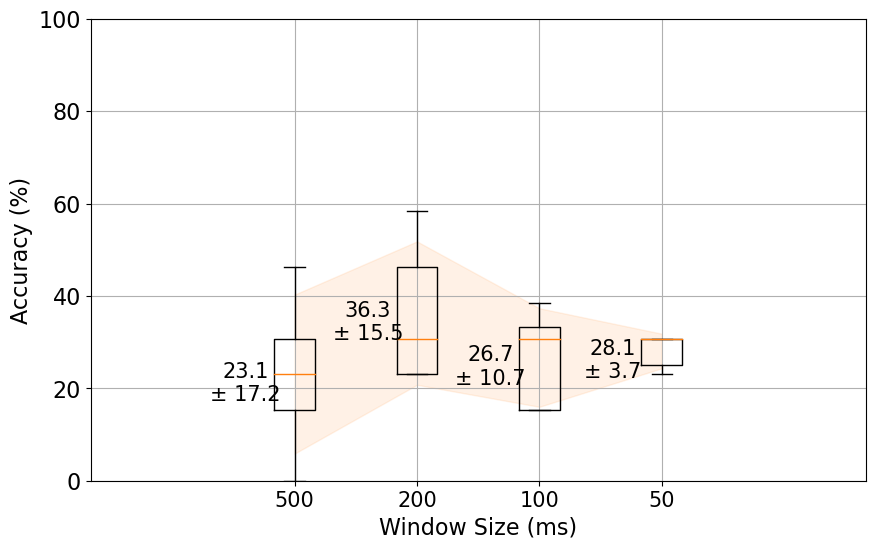

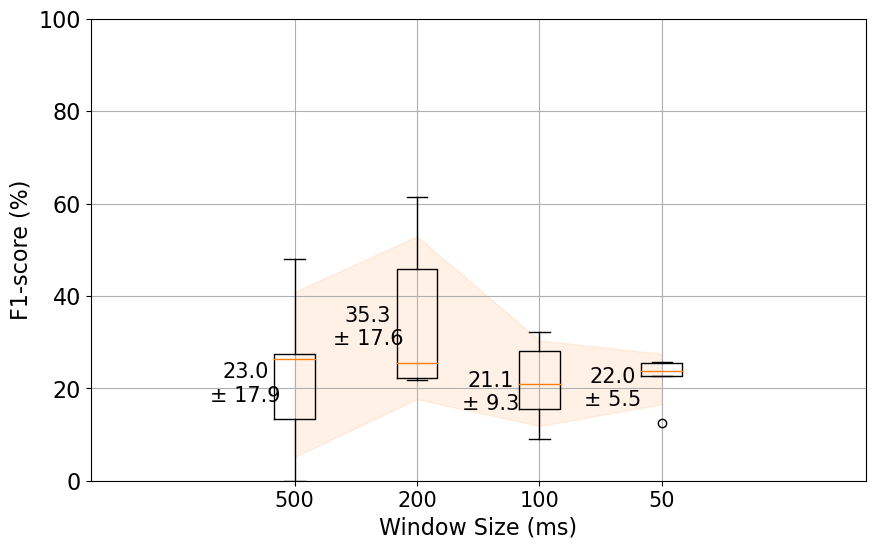

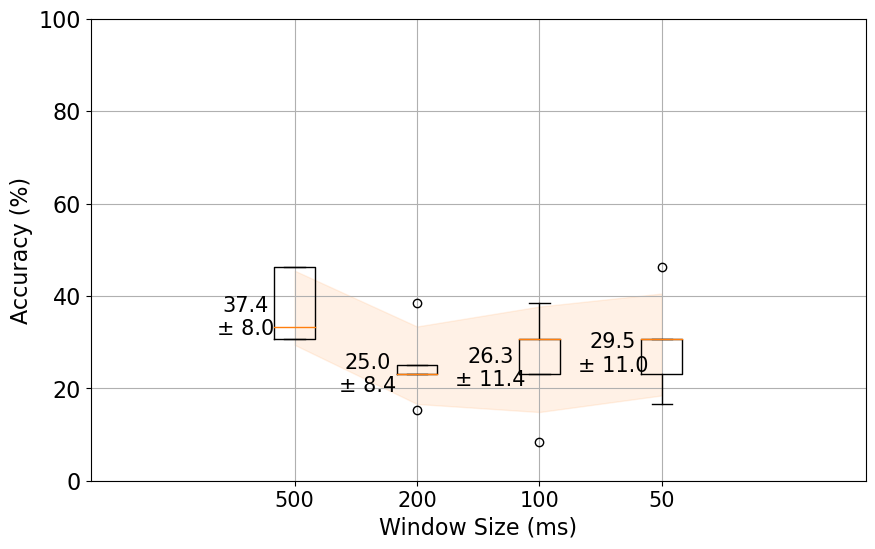

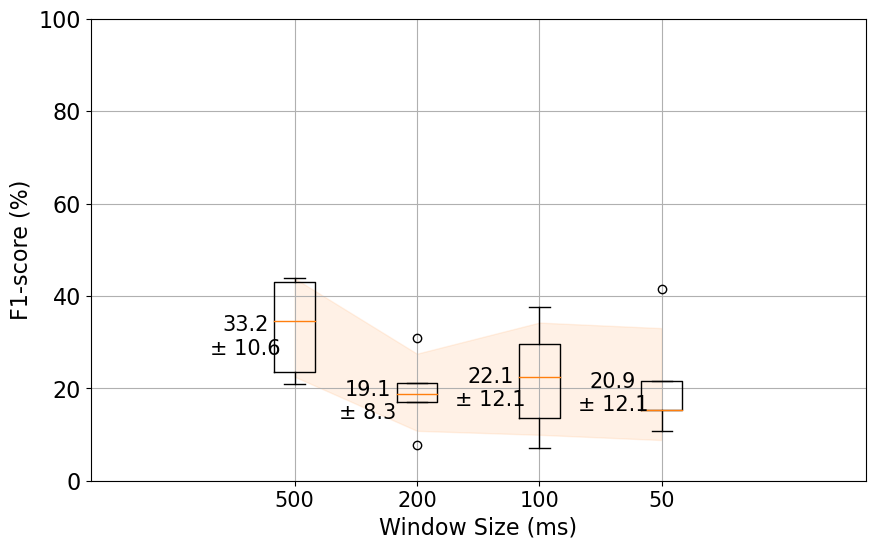

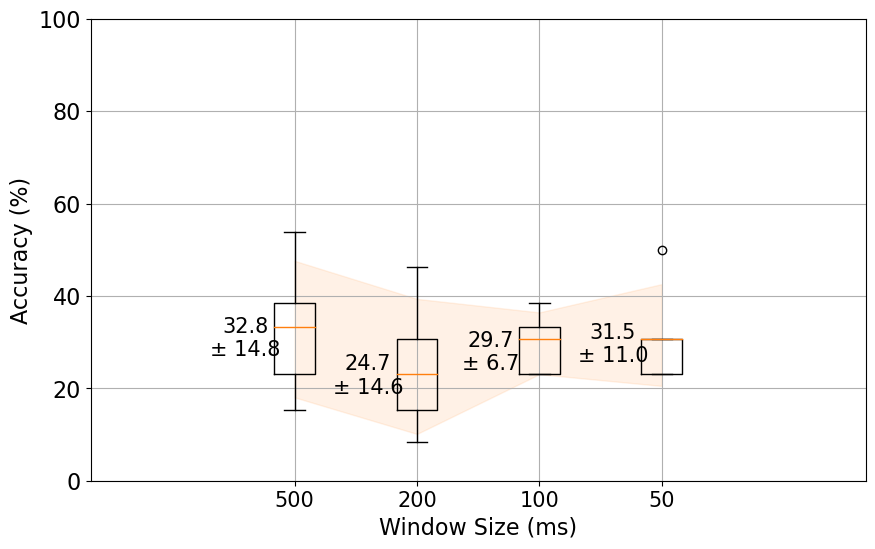

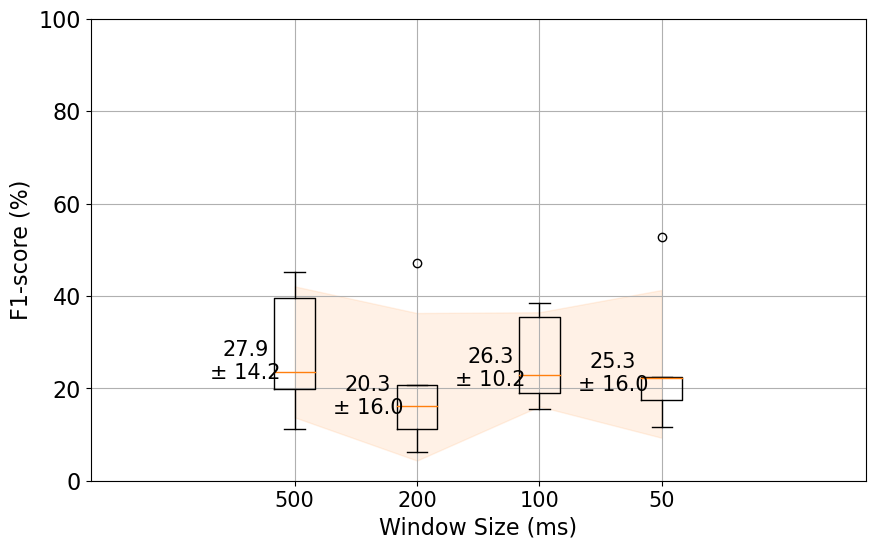

In [8]:
for animal_folder, data in animal_data.items():
    if data['accuracy_data']:
        create_accuracy_boxplot(data['accuracy_data'], data['window_sizes'], animal_folder, path_boxplots,  T_or_V, ymin)
    if data['f1score_data']:
        create_f1score_boxplot(data['f1score_data'], data['window_sizes'], animal_folder, path_boxplots,  T_or_V, ymin)      
    else:
        print(f"No data available for {animal_folder} in {T_or_V}. Skipping boxplot creation.")

In [9]:
T_or_V='Test'
animal_data=get_animal_data(path_classifier, T_or_V)
print(animal_data)

{'Animal 1': {'window_sizes': [500, 200, 100, 50], 'accuracy_data': [array([25.  , 31.25, 25.  , 31.25, 37.5 ]), array([12.5 ,  0.  , 12.5 , 37.5 ,  6.25]), array([12.5 , 18.75, 18.75, 12.5 , 25.  ]), array([25.  , 18.75, 25.  ,  6.25, 18.75])], 'f1score_data': [array([18.18181818, 25.82417582, 23.33333333, 25.        , 32.36111111]), array([19.64285714,  0.        , 10.        , 37.00396825,  4.54545455]), array([ 9.09090909, 21.11111111, 14.95726496, 12.14285714, 20.57109557]), array([21.97802198, 17.14285714, 16.26984127,  5.55555556, 19.12878788])]}, 'Animal 2': {'window_sizes': [500, 200, 100, 50], 'accuracy_data': [array([12.5 , 18.75, 18.75, 18.75, 37.5 ]), array([12.5 ,  6.25, 12.5 ,  6.25, 18.75]), array([31.25, 18.75, 18.75, 31.25, 25.  ]), array([18.75, 25.  , 25.  , 25.  , 18.75])], 'f1score_data': [array([10.09615385, 17.69230769, 16.02564103, 17.69230769, 34.28571429]), array([ 6.25      ,  6.25      , 12.87878788,  5.55555556, 14.16666667]), array([29.36507937, 16.111111

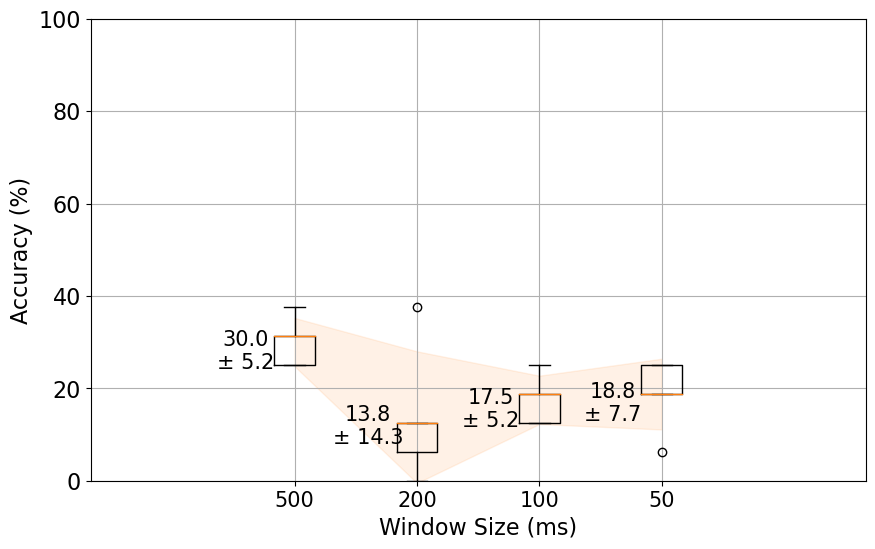

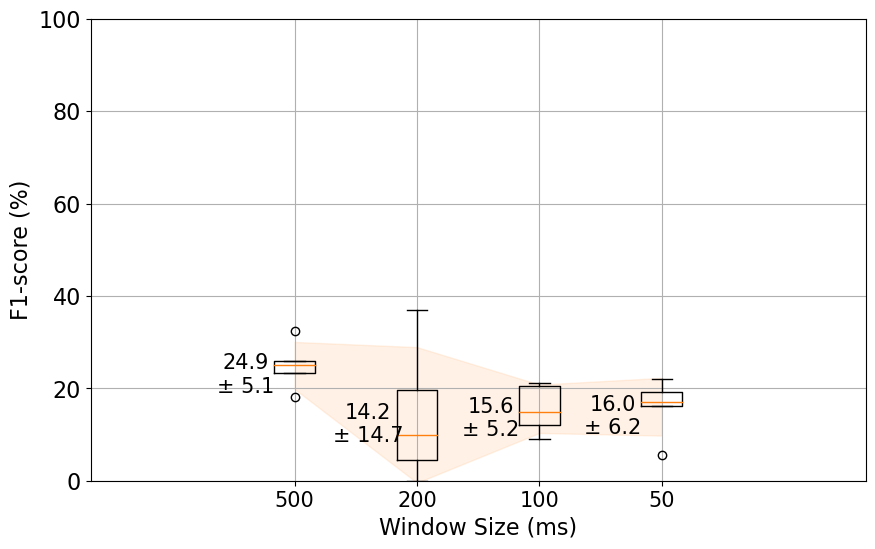

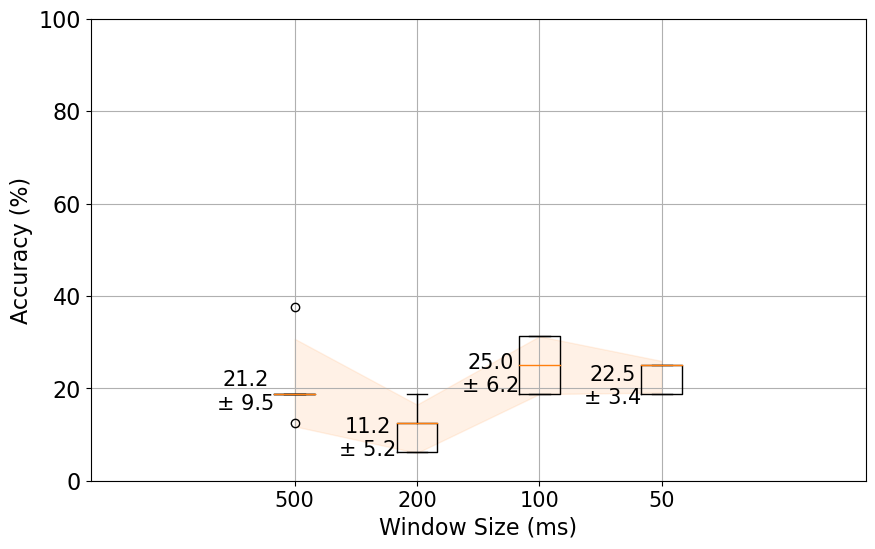

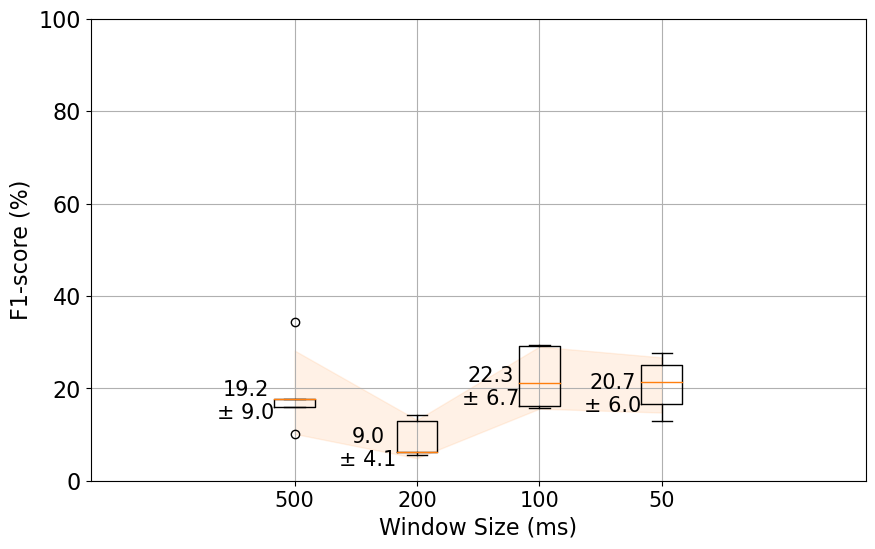

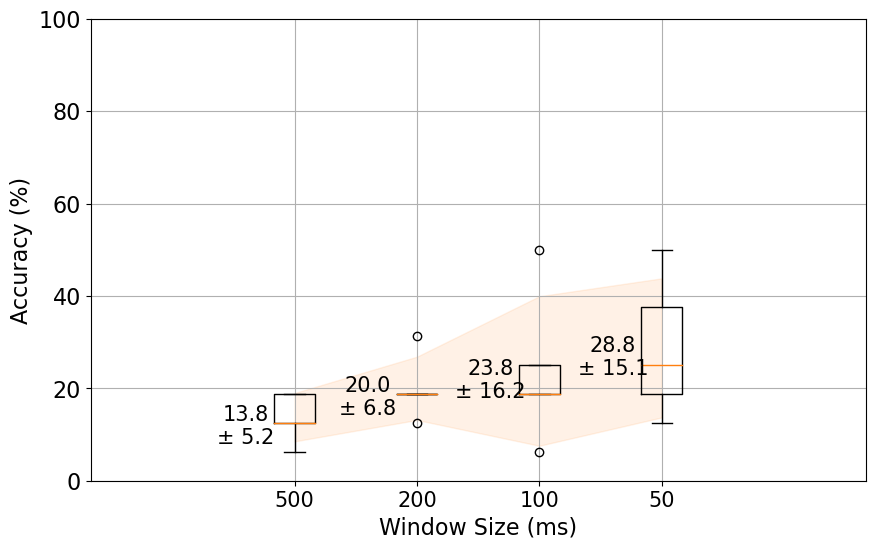

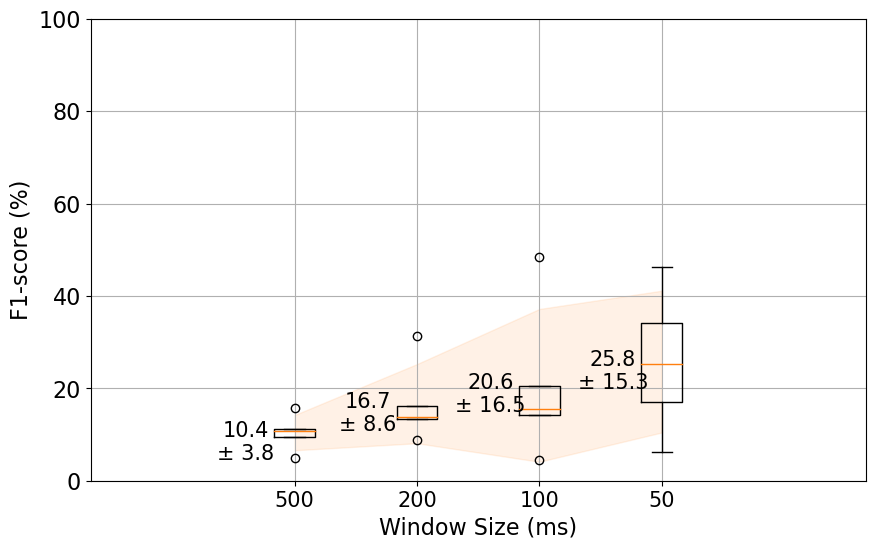

In [10]:
for animal_folder, data in animal_data.items():
    if data['accuracy_data']:
        create_accuracy_boxplot(data['accuracy_data'], data['window_sizes'], animal_folder, path_boxplots,  T_or_V, ymin)
    if data['f1score_data']:
        create_f1score_boxplot(data['f1score_data'], data['window_sizes'], animal_folder, path_boxplots,  T_or_V, ymin)
    else:
        print(f"No data available for {animal_folder} in {T_or_V}. Skipping boxplot creation.")

# BoxPlot with windows comparison 
This section needs all animal 1,2,3 and all windows 50,100,200,500 ms. It will be done for Validation and then Testing.

In [11]:
# SET VALIDATION 
T_or_V='Validation'
animal_data=get_animal_data(path_classifier, T_or_V)

# Creazione dei gruppi di dati per ciascuna finestra di tempo
accuracy_w500 = [animal_data[animal]['accuracy_data'][0] for animal in animal_data]
accuracy_w200 = [animal_data[animal]['accuracy_data'][1] for animal in animal_data]
accuracy_w100 = [animal_data[animal]['accuracy_data'][2] for animal in animal_data]
accuracy_w50 = [animal_data[animal]['accuracy_data'][3] for animal in animal_data]

f1score_w500 = [animal_data[animal]['f1score_data'][0] for animal in animal_data]
f1score_w200 = [animal_data[animal]['f1score_data'][1] for animal in animal_data]
f1score_w100 = [animal_data[animal]['f1score_data'][2] for animal in animal_data]
f1score_w50 = [animal_data[animal]['f1score_data'][3] for animal in animal_data]

### Validation windows comparison Accuracy

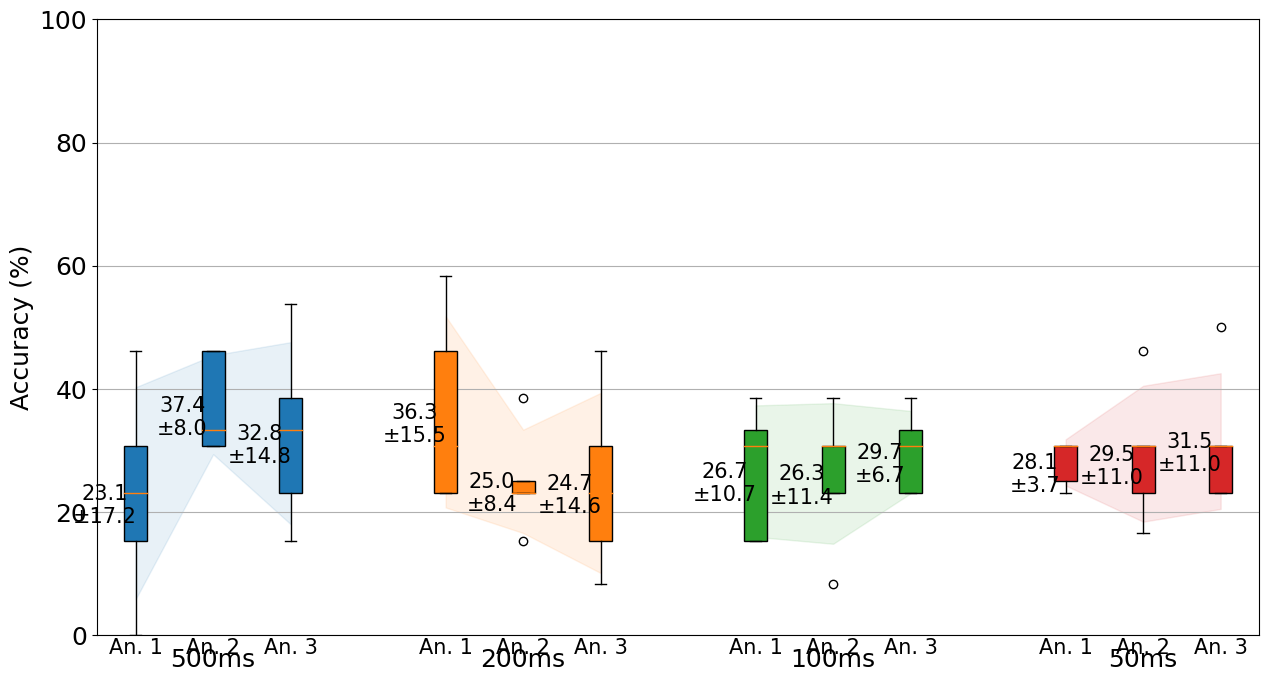

In [12]:
w_compare_acc_boxplots(accuracy_w500, accuracy_w200, accuracy_w100, accuracy_w50, path_boxplots, T_or_V, ymin)

### Validation windows comparison F1-score

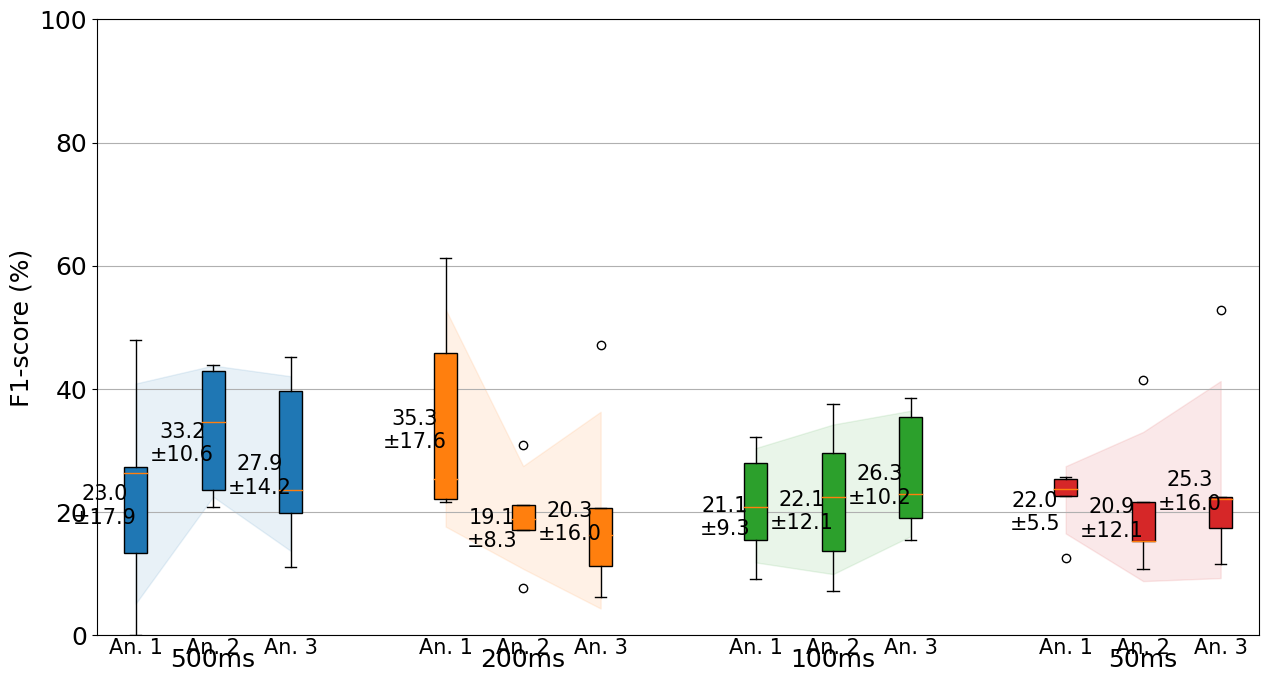

In [13]:
w_compare_f1_boxplots(f1score_w500, f1score_w200, f1score_w100, f1score_w50, path_boxplots, T_or_V, ymin)

### Testing windows comparison Accuracy

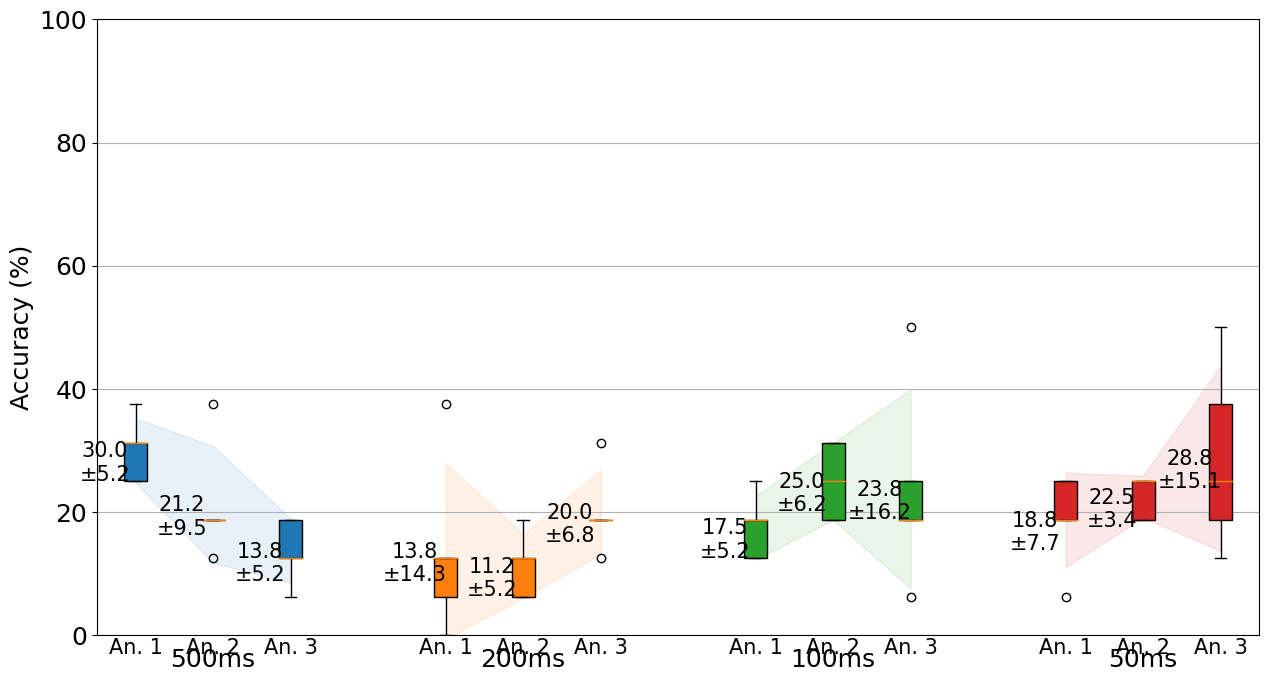

In [14]:
# SET TEST 
T_or_V='Test'
animal_data=get_animal_data(path_classifier, T_or_V)

# Creazione dei gruppi di dati per ciascuna finestra di tempo
accuracy_w500 = [animal_data[animal]['accuracy_data'][0] for animal in animal_data]
accuracy_w200 = [animal_data[animal]['accuracy_data'][1] for animal in animal_data]
accuracy_w100 = [animal_data[animal]['accuracy_data'][2] for animal in animal_data]
accuracy_w50 = [animal_data[animal]['accuracy_data'][3] for animal in animal_data]

f1score_w500 = [animal_data[animal]['f1score_data'][0] for animal in animal_data]
f1score_w200 = [animal_data[animal]['f1score_data'][1] for animal in animal_data]
f1score_w100 = [animal_data[animal]['f1score_data'][2] for animal in animal_data]
f1score_w50 = [animal_data[animal]['f1score_data'][3] for animal in animal_data]

w_compare_acc_boxplots(accuracy_w500, accuracy_w200, accuracy_w100, accuracy_w50, path_boxplots, T_or_V, ymin)

### Testing windows comparison F1-score

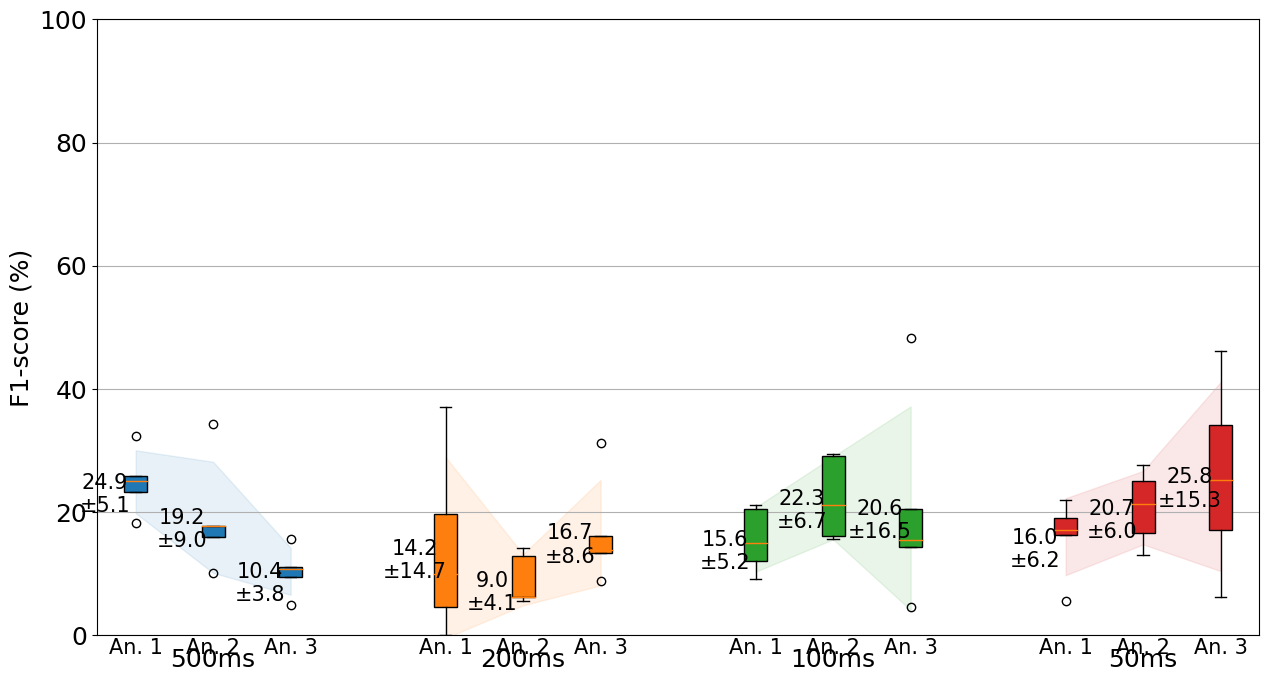

In [15]:
w_compare_f1_boxplots(f1score_w500, f1score_w200, f1score_w100, f1score_w50, path_boxplots, T_or_V, ymin)

# Boxplot with dataset 1 comparison
This section needs all animal 1,2,3 and all windows 50,100,200,500 ms. It will be done for Validation and then Testing.

In [16]:
# Lista contenente le etichette delle finestre di tempo per l'asse x
window_sizes = ["500", "200", "100", "50"]

In [17]:
#print(animal_data)

## Validation 

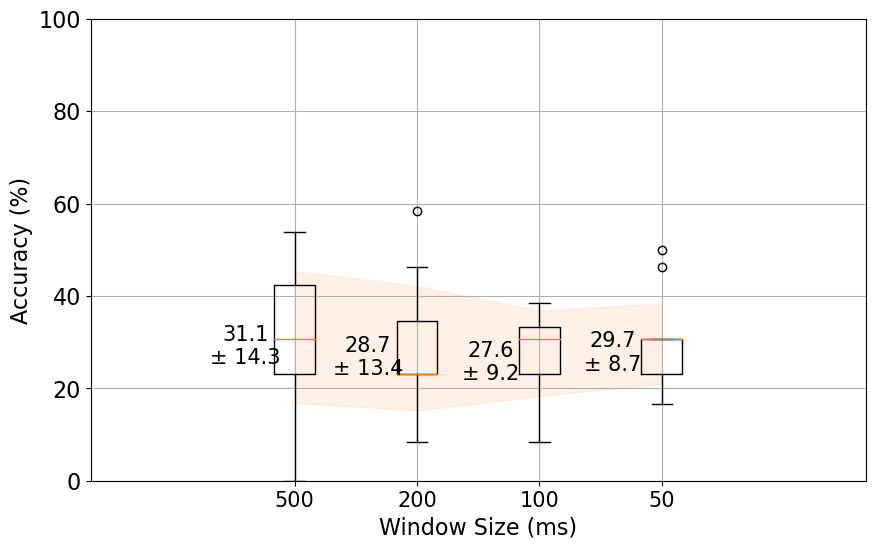

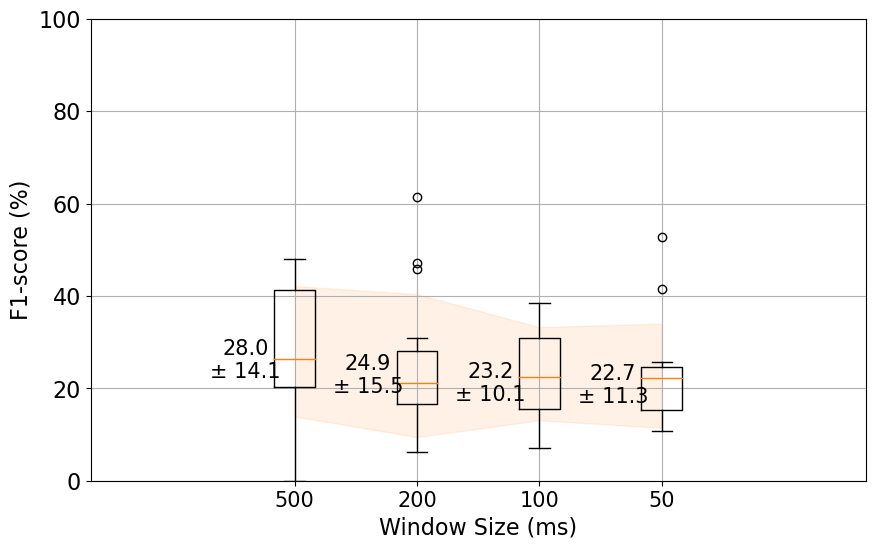

In [18]:
T_or_V='Validation'
animal_data=get_animal_data(path_classifier, T_or_V)

# Creazione dei gruppi di dati per ciascuna finestra di tempo
accuracy_w500 = [animal_data[animal]['accuracy_data'][0] for animal in animal_data]
accuracy_w200 = [animal_data[animal]['accuracy_data'][1] for animal in animal_data]
accuracy_w100 = [animal_data[animal]['accuracy_data'][2] for animal in animal_data]
accuracy_w50 = [animal_data[animal]['accuracy_data'][3] for animal in animal_data]

f1score_w500 = [animal_data[animal]['f1score_data'][0] for animal in animal_data]
f1score_w200 = [animal_data[animal]['f1score_data'][1] for animal in animal_data]
f1score_w100 = [animal_data[animal]['f1score_data'][2] for animal in animal_data]
f1score_w50 = [animal_data[animal]['f1score_data'][3] for animal in animal_data]

accuracy_w500 = np.array(accuracy_w500).flatten()
accuracy_w200 =  np.array(accuracy_w200).flatten()
accuracy_w100 =  np.array(accuracy_w100).flatten()
accuracy_w50 =  np.array(accuracy_w50).flatten()

f1score_w500 =  np.array(f1score_w500).flatten()
f1score_w200 =  np.array(f1score_w200).flatten()
f1score_w100 = np.array(f1score_w100).flatten()
f1score_w50 =  np.array(f1score_w50).flatten()

# Creazione di una lista di array contenenti i valori di accuracy_wX
accuracy_data = [accuracy_w500, accuracy_w200, accuracy_w100, accuracy_w50]
f1score_data = [f1score_w500, f1score_w200, f1score_w100, f1score_w50]

# Create and save the boxplot for accuracy
create_accuracy_boxplot(accuracy_data, window_sizes, 'Dataset 1', path_boxplots, T_or_V, ymin)

# Create and save the boxplot for F1-score
create_f1score_boxplot(f1score_data, window_sizes, 'Dataset 1', path_boxplots, T_or_V, ymin)

## Testing

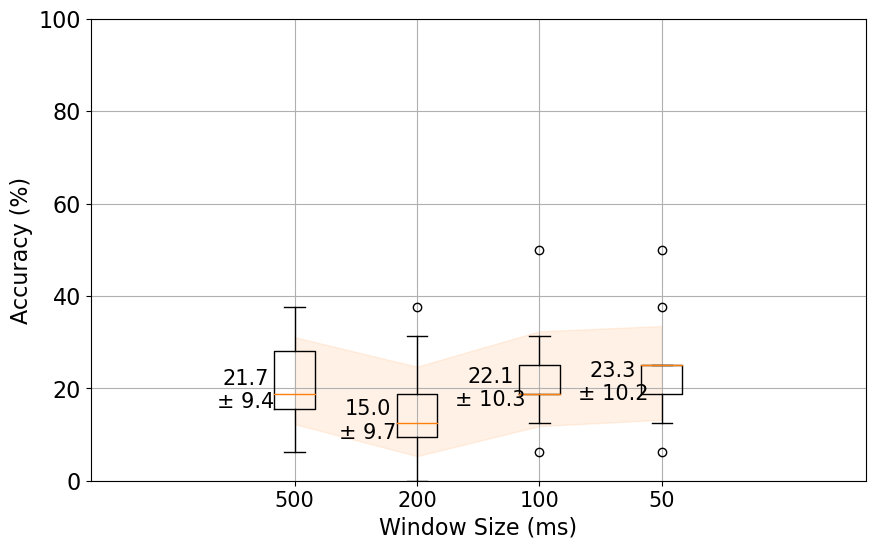

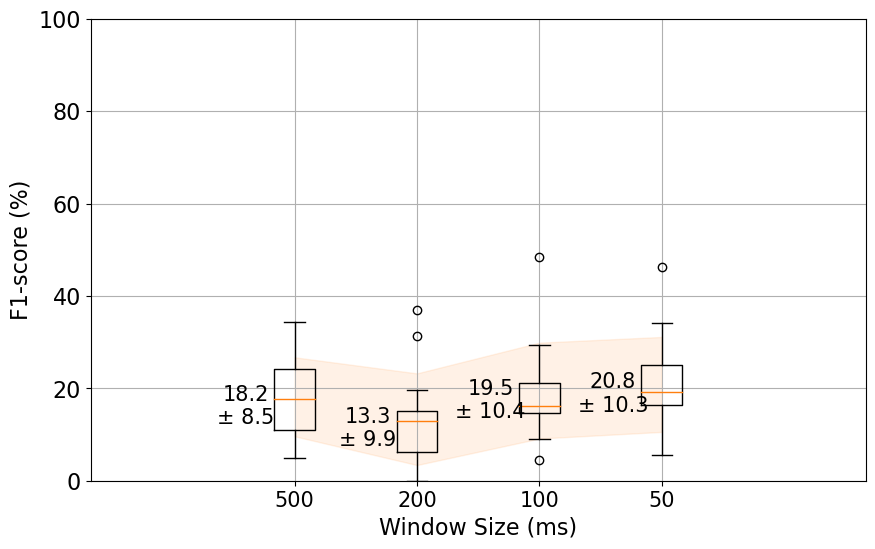

In [19]:
T_or_V='Test'
animal_data=get_animal_data(path_classifier, T_or_V)

# Creazione dei gruppi di dati per ciascuna finestra di tempo
accuracy_w500 = [animal_data[animal]['accuracy_data'][0] for animal in animal_data]
accuracy_w200 = [animal_data[animal]['accuracy_data'][1] for animal in animal_data]
accuracy_w100 = [animal_data[animal]['accuracy_data'][2] for animal in animal_data]
accuracy_w50 = [animal_data[animal]['accuracy_data'][3] for animal in animal_data]

f1score_w500 = [animal_data[animal]['f1score_data'][0] for animal in animal_data]
f1score_w200 = [animal_data[animal]['f1score_data'][1] for animal in animal_data]
f1score_w100 = [animal_data[animal]['f1score_data'][2] for animal in animal_data]
f1score_w50 = [animal_data[animal]['f1score_data'][3] for animal in animal_data]

accuracy_w500 = np.array(accuracy_w500).flatten()
accuracy_w200 =  np.array(accuracy_w200).flatten()
accuracy_w100 =  np.array(accuracy_w100).flatten()
accuracy_w50 =  np.array(accuracy_w50).flatten()

f1score_w500 =  np.array(f1score_w500).flatten()
f1score_w200 =  np.array(f1score_w200).flatten()
f1score_w100 = np.array(f1score_w100).flatten()
f1score_w50 =  np.array(f1score_w50).flatten()

# Creazione di una lista di array contenenti i valori di accuracy_wX
accuracy_data = [accuracy_w500, accuracy_w200, accuracy_w100, accuracy_w50]
f1score_data = [f1score_w500, f1score_w200, f1score_w100, f1score_w50]

# Create and save the boxplot for accuracy
create_accuracy_boxplot(accuracy_data, window_sizes, 'Dataset 1', path_boxplots, T_or_V, ymin)

# Create and save the boxplot for F1-score
create_f1score_boxplot(f1score_data, window_sizes, 'Dataset 1', path_boxplots, T_or_V, ymin)